Test the flat-entanglement-energy prediction
Define $E_L=\log[(1+L)/(1-L)]$. A constant unnormalized energy density predicts $\overline N_L(A_y)=2E_L n_0(A_y)$ and hence $b(L)/E_L$ independent of L for common log-chord fits. Test this using the unrounded saved results and all 100 trajectory-resolved coefficient vectors; all 32 origins were averaged within trajectories.
The reference L=0.99 fixes the predicted normalization without fitting. Paired errors retain correlations between windows. Deviations assess the flat-density approximation; they do not identify their microscopic cause. The fit range is Ay=5..16, Nx20 Ny32, hard walls, alpha1=1, pure-state cycle64 endpoints.

In [1]:
import os
CPU_RANGE=(40,41)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for k in ['OPENBLAS_NUM_THREADS','OMP_NUM_THREADS']:os.environ[k]='1'
print('CPUs:',selected)

CPUs: [40, 41]


Validate source data and reconstruct fits

In [2]:
from pathlib import Path
import json,hashlib,shutil,subprocess
import numpy as np
import pandas as pd
from IPython.display import display,Image
OUT=Path.cwd();SOURCE=OUT.parent/'mean_mode_count_window_scan_n20x32_v1'
def sha(p):return hashlib.sha256(p.read_bytes()).hexdigest()
manifest=json.loads((SOURCE/'completion_manifest.json').read_text())
inputs=[]
for name in ['window_scan_statistics.npz','window_fit_summary.csv']:
 p=SOURCE/name;r=manifest['files'][name]
 assert p.stat().st_size==r['bytes'] and sha(p)==r['sha256']
 inputs.append(dict(path=str(p),**r))
with np.load(SOURCE/'window_scan_statistics.npz') as z:
 L=z['L_values'];widths=z['widths'];tc=z['trajectory_counts'];co=z['trajectory_coefficients']
 assert np.array_equal(z['sample_ids'],np.arange(100)) and np.array_equal(z['origins'],np.arange(32))
 assert np.allclose(tc,z['counts'].mean(-1))
fits=pd.read_csv(SOURCE/'window_fit_summary.csv')
assert np.allclose(fits.L,L) and (fits.fit_min_width==5).all() and (fits.fit_max_width==16).all()
logd=np.log(32/np.pi*np.sin(np.pi*widths/32));mask=(widths>=5)&(widths<=16)
X=np.column_stack([np.ones(mask.sum()),logd[mask]]);op=np.linalg.pinv(X)
reconstructed=np.einsum('pa,ska->skp',op,tc[:,:,mask])
assert np.allclose(reconstructed,co,atol=1e-11)
assert np.allclose(co[:,:,1].mean(0),fits.slope) and np.allclose(co[:,:,1].std(0,ddof=1)/10,fits.slope_sem)
E=np.log1p(L)-np.log1p(-L);ref=int(np.flatnonzero(np.isclose(L,.99,atol=1e-14,rtol=0))[0])
normalized=co[:,:,1]/E[None,:]
diff=normalized-normalized[:,ref,None]
rng=np.random.default_rng(2026100501)
weights=rng.multinomial(100,np.full(100,.01),size=5000)/100
boot=weights@normalized
ratio=boot/boot[:,ref,None]-1
cis=np.quantile(ratio,[.025,.975],axis=0)
table=fits[['L','slope','slope_sem','R_squared']].copy()
table['energy_half_width']=E
table['b_over_energy_half_width']=normalized.mean(0)
table['normalized_slope_sem']=normalized.std(0,ddof=1)/10
table['prediction_from_L099']=fits.slope.iloc[ref]*E/E[ref]
table['fractional_deviation']=normalized.mean(0)/normalized[:,ref].mean()-1
table['fractional_deviation_ci_low']=cis[0];table['fractional_deviation_ci_high']=cis[1]
table['paired_difference']=diff.mean(0);table['paired_difference_sem']=diff.std(0,ddof=1)/10
table.to_csv(OUT/'width_scaling_test.csv',index=False)
scaled_counts=tc/(2*E[None,:,None])
rows=[]
for k,l in enumerate(L):
 for j,a in enumerate(widths):
  v=scaled_counts[:,k,j]
  rows.append(dict(L=float(l),Ay=int(a),log_chord=float(logd[j]),mean_density=float(v.mean()),sem=float(v.std(ddof=1)/10)))
curves=pd.DataFrame(rows);curves.to_csv(OUT/'counts_per_energy_width.csv',index=False)
# Scaling each curve by a constant must leave its R-squared unchanged.
mean=scaled_counts.mean(0);beta=mean[:,mask]@op.T;pred=beta@X.T
r2=1-((mean[:,mask]-pred)**2).sum(1)/((mean[:,mask]-mean[:,mask].mean(1,keepdims=True))**2).sum(1)
assert np.allclose(r2,fits.R_squared,atol=1e-12)
display(table)

,L,slope,slope_sem,R_squared,energy_half_width,b_over_energy_half_width,normalized_slope_sem,prediction_from_L099,fractional_deviation,fractional_deviation_ci_low,fractional_deviation_ci_high,paired_difference,paired_difference_sem
0,0.10000,0.038174,0.010132,0.588983,0.200671,0.190230,0.050489,0.045015,-1.519830e-01,-0.587354,0.282156,-0.034093,0.050526
1,0.20000,0.081062,0.012411,0.931211,0.405465,0.199923,0.030608,0.090955,-1.087764e-01,-0.369637,0.155982,-0.024401,0.030631
2,0.30000,0.148971,0.010939,0.964696,0.619039,0.240649,0.017671,0.138865,7.277610e-02,-0.085318,0.226187,0.016325,0.017977
3,0.40000,0.164639,0.010043,0.990452,0.847298,0.194311,0.011853,0.190069,-1.337935e-01,-0.231740,-0.037731,-0.030013,0.011491
4,0.50000,0.229814,0.011763,0.988941,1.098612,0.209186,0.010707,0.246445,-6.748132e-02,-0.160262,0.026998,-0.015138,0.010788
5,0.60000,0.307496,0.009036,0.992577,1.386294,0.221812,0.006518,0.310979,-1.119836e-02,-0.071492,0.049970,-0.002512,0.007050
6,0.70000,0.378885,0.011002,0.998261,1.734601,0.218428,0.006343,0.389112,-2.628432e-02,-0.085567,0.033005,-0.005896,0.006844
7,0.80000,0.471908,0.008018,0.997686,2.197225,0.214775,0.003649,0.492890,-4.256773e-02,-0.078448,-0.006830,-0.009549,0.004163
8,0.90000,0.627313,0.009381,0.998285,2.944439,0.213050,0.003186,0.660508,-5.025662e-02,-0.082619,-0.016998,-0.011274,0.003952
9,0.95000,0.779166,0.010755,0.998054,3.663562,0.212680,0.002936,0.821824,-5.190608e-02,-0.083591,-0.019108,-0.011644,0.003782


Slope scaling
The dashed prediction is anchored at L=0.99. Error bars show one trajectory SEM; no independent-window approximation is used for the paired deviations saved above.

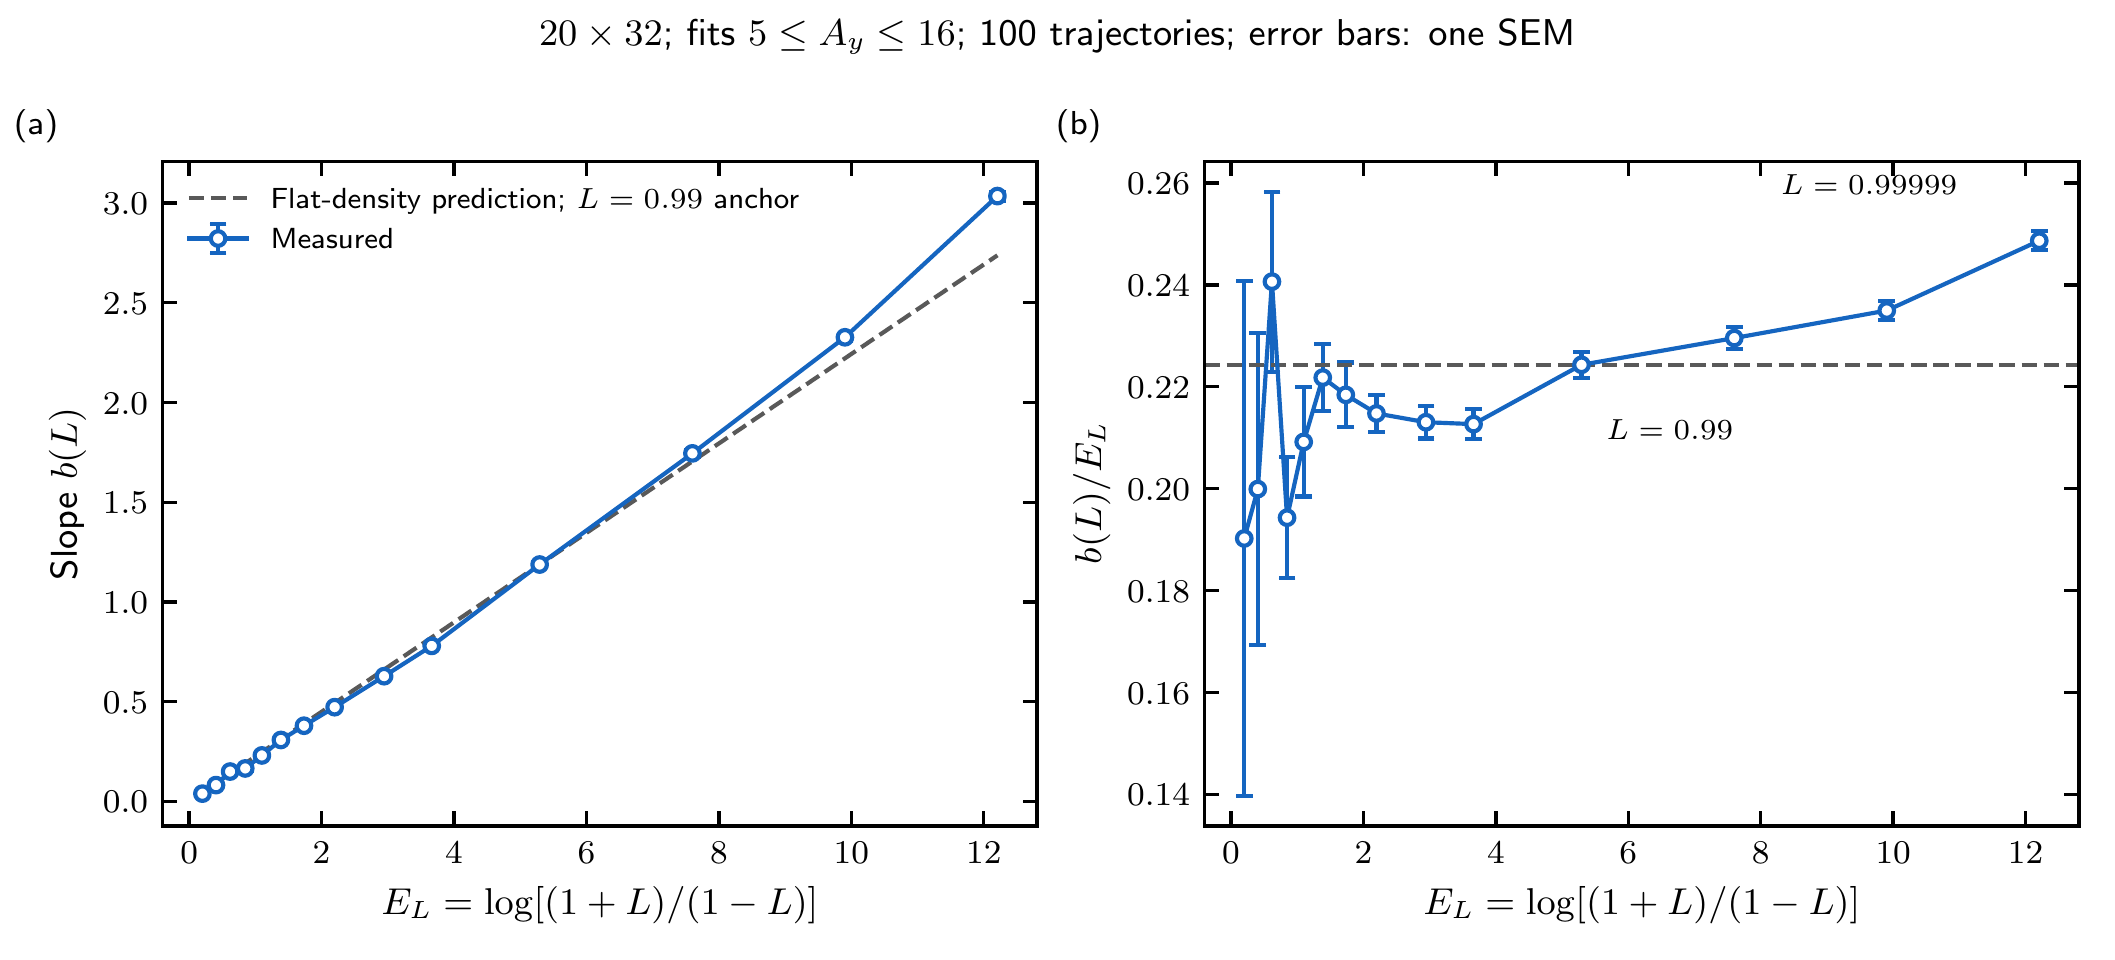

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
shutil.copytree(SOURCE/'latex_support',OUT/'latex_support',dirs_exist_ok=True)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':9,'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}',
 'xtick.direction':'in','ytick.direction':'in','legend.frameon':False,'legend.fontsize':7})
fig,axes=plt.subplots(1,2,figsize=(7.05,3.2))
axes[0].errorbar(E,fits.slope,yerr=fits.slope_sem,fmt='o-',color='#1565c0',mfc='white',ms=3.5,lw=1,capsize=2,label='Measured')
axes[0].plot(E,table.prediction_from_L099,'--',color='.35',lw=1,label=r'Flat-density prediction; $L=0.99$ anchor')
axes[0].set(xlabel=r'$E_L=\log[(1+L)/(1-L)]$',ylabel=r'Slope $b(L)$')
axes[0].legend(loc='upper left')
axes[1].errorbar(E,normalized.mean(0),yerr=normalized.std(0,ddof=1)/10,fmt='o-',color='#1565c0',mfc='white',ms=3.5,lw=1,capsize=2)
axes[1].axhline(normalized[:,ref].mean(),color='.35',ls='--',lw=1)
axes[1].set(xlabel=r'$E_L=\log[(1+L)/(1-L)]$',ylabel=r'$b(L)/E_L$')
for k,offset in [(ref,(6,-18)),(13,(-62,11))]:
 axes[1].annotate(r'$L='+str(L[k])+'$',(E[k],normalized[:,k].mean()),xytext=offset,textcoords='offset points',fontsize=7)
for ax,label in zip(axes,['(a)','(b)']):
 ax.tick_params(top=True,right=True);ax.text(-.17,1.04,label,transform=ax.transAxes)
fig.suptitle(r'$20\times32$; fits $5\le A_y\le16$; 100 trajectories; error bars: one SEM',fontsize=9)
fig.tight_layout()
fig.savefig(OUT/'slope_vs_energy_window.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'slope_vs_energy_window.pdf'),str(OUT/'slope_vs_energy_window')],check=True)
display(Image(filename=str(OUT/'slope_vs_energy_window.png'),width=1100))

Mode counts divided by energy-window width
Exact constant energy density over all tested windows would collapse these curves. The gray region identifies the log-chord fit range. Both intercept and slope may deviate from collapse.

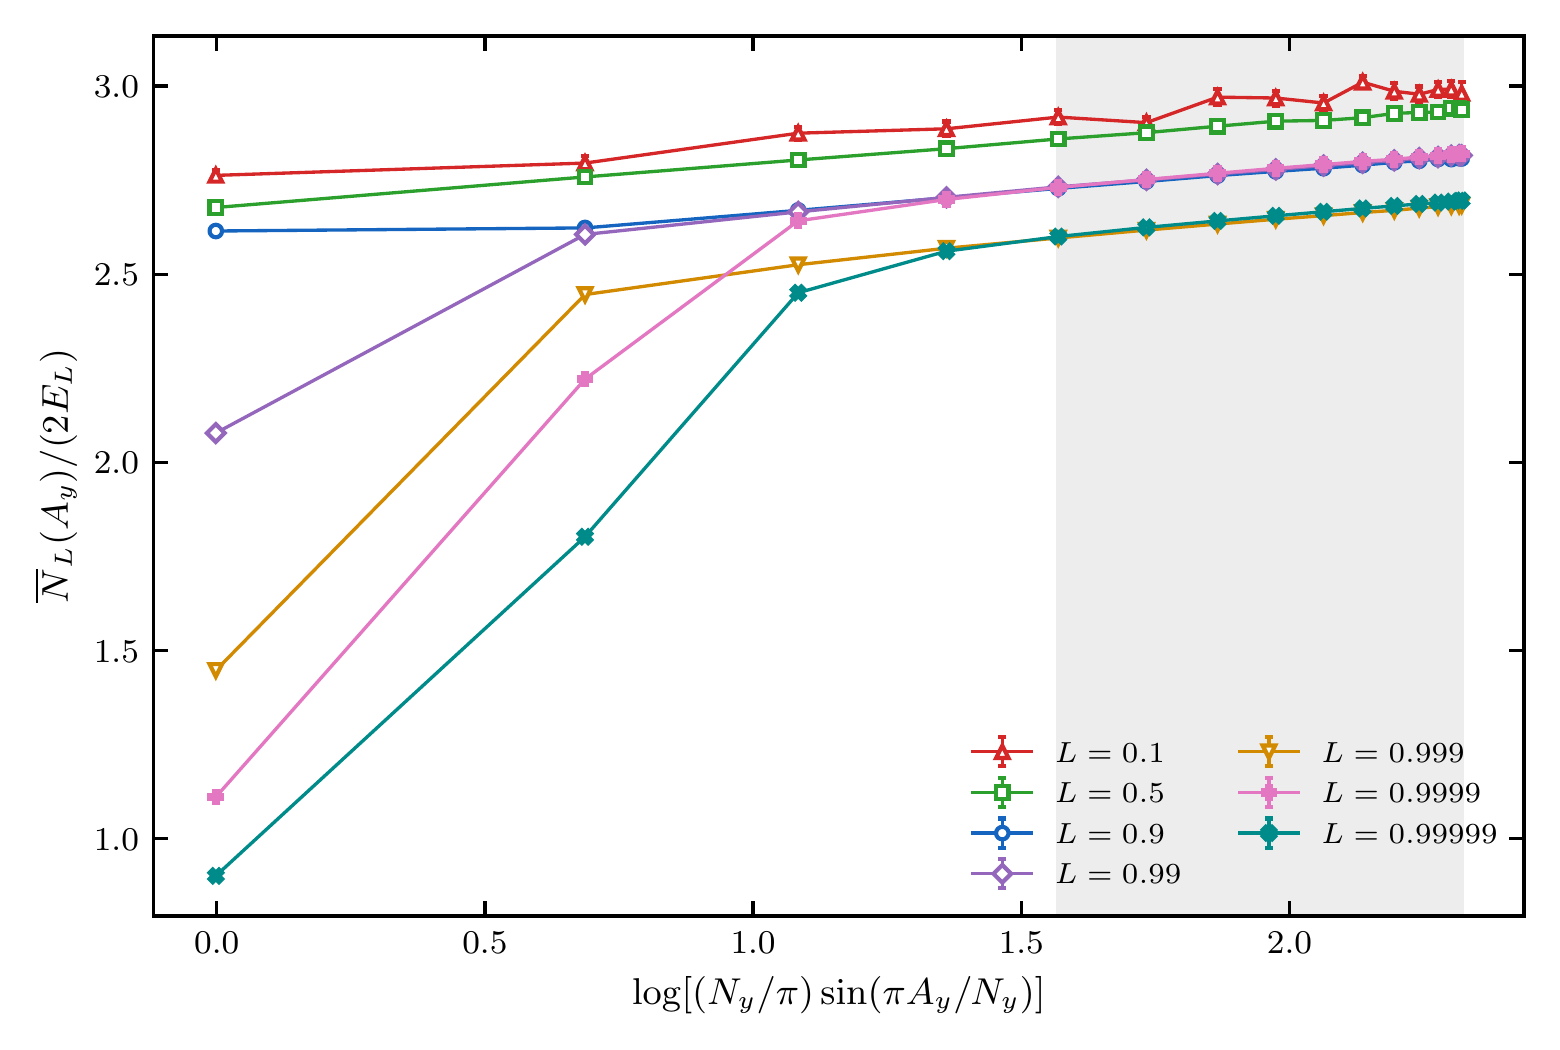

In [4]:
fig,ax=plt.subplots(figsize=(5.2,3.5))
ax.axvspan(logd[4],logd[-1],color='.93')
selected=[.1,.5,.9,.99,.999,.9999,.99999]
for l,color,marker in zip(selected,['#d62728','#2ca02c','#1565c0','#9467bd','#d28a00','#e377c2','#008b8b'],['^','s','o','D','v','P','X']):
 k=int(np.flatnonzero(np.isclose(L,l,atol=1e-14,rtol=0))[0]);v=scaled_counts[:,k,:]
 ax.errorbar(logd,v.mean(0),yerr=v.std(0,ddof=1)/10,color=color,marker=marker,mfc='white',ms=3,lw=.8,capsize=1,
 label=r'$L='+str(l)+'$')
ax.set(xlabel=r'$\log[(N_y/\pi)\sin(\pi A_y/N_y)]$',ylabel=r'$\overline N_L(A_y)/(2E_L)$')
ax.tick_params(top=True,right=True);ax.legend(ncol=2,loc='lower right',fontsize=7)
fig.tight_layout()
fig.savefig(OUT/'counts_divided_by_energy_width.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'counts_divided_by_energy_width.pdf'),str(OUT/'counts_divided_by_energy_width')],check=True)
display(Image(filename=str(OUT/'counts_divided_by_energy_width.png'),width=1000))

Diagnostics
The numerical check tests the stronger hypothesis of an exactly constant unnormalized energy density at every subsystem size. Conditional flatness at Ay16 and L0.99 alone does not imply this hypothesis.

In [5]:
diagnostics=dict(inputs=inputs,reference_L=.99,samples=100,origins_per_sample=32,fit_Ay=[5,16],
 bootstrap_replicates=5000,bootstrap_seed=2026100501,independent_unit='whole trajectory, paired across windows',
 r_squared_invariance_max_error=float(np.max(abs(r2-fits.R_squared))),
 source='unrounded saved spectra-derived count statistics',new_simulations=0,
 interpretation='Window-width transformation explains most slope growth. Residual normalized-slope dependence is resolved, especially near L=1; exact flatness/separability is an approximation.')
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.Series(diagnostics))

inputs                            [{'path': '/home/abhuiyan/class_A_fermionic_ad...
reference_L                                                                    0.99
samples                                                                         100
origins_per_sample                                                               32
fit_Ay                                                                      [5, 16]
bootstrap_replicates                                                           5000
bootstrap_seed                                                           2026100501
independent_unit                            whole trajectory, paired across windows
r_squared_invariance_max_error                                                  0.0
source                             unrounded saved spectra-derived count statistics
new_simulations                                                                   0
interpretation                    Window-width transformation explains most 